# EOD PCA-SVM Momentum Query Backtest

End-of-day PCA-SVM momentum classification on `USD-SOFR-1D-Q12STIRT` / `IMM_4xIMM_5`
using the original Matlab `pfBBGDailySVM` parameters.

**Algorithm (Matlab port):**
1. EMA-SMA spreads for short=[7, 14, 20] / long=[50, 75, 100] windows + cross-spreads → feature matrix
2. Feature normalization (StandardScaler) → PCA projection to 2 components
3. Backward-looking momentum z-score (window=10) → labels {-1, 0, +1} via z_threshold=1.75
4. SVM (RBF kernel, C=0.02, γ=0.1) trained on initial 70% of data, predictions on remaining 30%

Data sourced from `BARCHART_STIRF-RL` at `nyc_eod` frequency (Jan 2023 – Mar 2026).

In [1]:
%load_ext autoreload
%autoreload 2

import datetime
import sys

import matplotlib.pyplot as plt
import pandas as pd
import pytz

sys.path.append("../../")

from BT.signals import pca_svm_momentum_signal, run_technical_indicator_query_backtest
from MDP.IRSwaps.IRSwapsMDP import IRSwapsMDP
from Query.IRSwaps.IRSwapQuery import IRSwapQuery
from Query.IRSwaps.IRSwapValue import IRSwapValue
from Query.Unified.UnifiedQuery import UnifiedQuery
from Query.Unified.registry import UnifiedValue
from TB.IRSwapsTB import IRSwapsTB
from TB.TimeseriesBuilder import TimeseriesBuilder

NYC = pytz.timezone("America/New_York")

In [20]:
# ── Load EOD data ────────────────────────────────────────────────────────
curve_mdp = IRSwapsMDP(source="BARCHART_STIRF-RL")
ts_builder = TimeseriesBuilder()
trade_bpv = 100_000.0

start = NYC.localize(datetime.datetime(2024, 3, 27, 18, 0))
end = NYC.localize(datetime.datetime(2026, 3, 27, 17, 0))

q = UnifiedQuery(
    curve="USD-SOFR-1D-Q12STIRT",
    tenor="IMM_4xIMM_5",
    value=UnifiedValue.IRS_RATE,
)

eod_df = ts_builder.get_timeseries(
    start=start,
    end=end,
    queries=[q],
    freq="nyc_eod",
    n_jobs=12,
    routers={
        "IRS": IRSwapsTB(curve_mdp, show_tqdm=True),
    },
    ignore_cache_miss=True,
)

rate_series = pd.to_numeric(eod_df.iloc[:, 0], errors="coerce").dropna()
rate_series.name = "IMM_4xIMM_5"

print(f"Loaded {len(rate_series)} EOD bars from {rate_series.index[0]} to {rate_series.index[-1]}")
rate_series

DuckDB unavailable (file locked), falling back to parquet-only: C:\Users\chris\clee\ARBS\data\ts\computed_ts.duckdb
                                                                                             

Loaded 498 EOD bars from 2024-03-28 17:00:00-04:00 to 2026-03-27 17:00:00-04:00


Date
2024-03-28 17:00:00-04:00    4.319926
2024-04-01 17:00:00-04:00    4.408491
2024-04-02 17:00:00-04:00    4.383831
2024-04-03 17:00:00-04:00    4.364182
2024-04-04 17:00:00-04:00    4.345659
                               ...   
2026-03-23 17:00:00-04:00    3.695188
2026-03-24 17:00:00-04:00    3.745343
2026-03-25 17:00:00-04:00    3.720608
2026-03-26 17:00:00-04:00    3.843609
2026-03-27 17:00:00-04:00    3.747259
Name: IMM_4xIMM_5, Length: 498, dtype: float64

In [31]:
# ── PCA-SVM Momentum signal — original Matlab pfBBGDailySVM parameters ───
signal_result = pca_svm_momentum_signal(
    rate_series,
    ewma_short_spans=[7, 14, 20],       
    ewma_long_spans=[50, 75, 100],      
    n_components=2,                      
    svm_c=0.02,                          
    svm_gamma=0.1,                       
    label_window=10,                     
    z_threshold=1.25,                    
    train_fraction=0.7,                  
    retrain_every=None,                  
)

display(signal_result.indicator_frame.tail())
display(
    pd.DataFrame(
        {
            "rate": signal_result.raw_series,
            "desired_position": signal_result.desired_position,
            "execution_position": signal_result.execution_position,
        }
    ).tail()
)

,momentum_zscore,label,decision_score,pc_1,pc_2
Date,,,,,
2026-03-23 17:00:00-04:00,5.329391,1.0,2.154970,-4.262266,2.052108
2026-03-24 17:00:00-04:00,5.214945,1.0,2.159374,-4.578929,2.192034
2026-03-25 17:00:00-04:00,3.794392,1.0,2.161669,-4.831108,2.129673
2026-03-26 17:00:00-04:00,3.847949,1.0,2.166630,-5.251755,2.148683
2026-03-27 17:00:00-04:00,3.079048,1.0,2.167139,-5.468962,1.684508


,rate,desired_position,execution_position
Date,,,
2026-03-23 17:00:00-04:00,3.695188,-1.0,-1.0
2026-03-24 17:00:00-04:00,3.745343,-1.0,-1.0
2026-03-25 17:00:00-04:00,3.720608,-1.0,-1.0
2026-03-26 17:00:00-04:00,3.843609,-1.0,-1.0
2026-03-27 17:00:00-04:00,3.747259,-1.0,-1.0


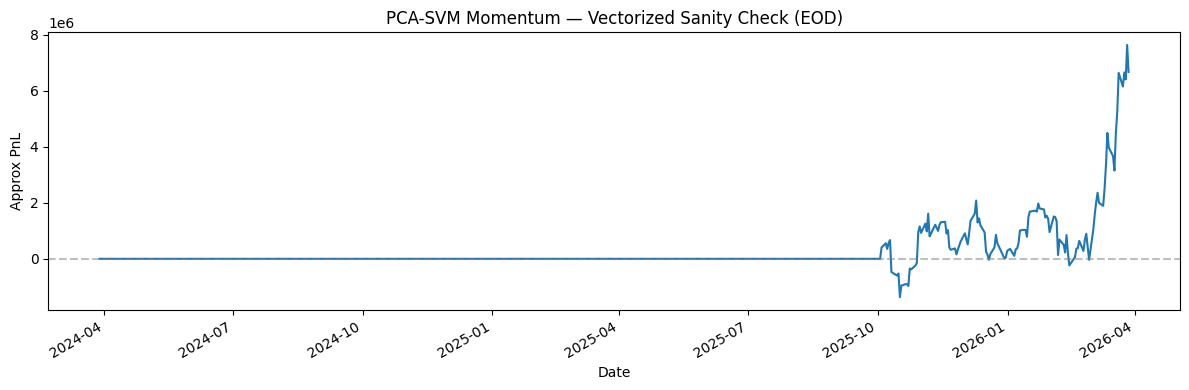

In [32]:
# ── Vectorized sanity check ──────────────────────────────────────────────
vectorized_position = signal_result.execution_position.fillna(0.0)
vectorized_pnl = -vectorized_position * rate_series.diff().fillna(0.0) * trade_bpv * 100.0
vectorized_cumulative_pnl = vectorized_pnl.cumsum()

fig, ax = plt.subplots(figsize=(12, 4))
vectorized_cumulative_pnl.plot(ax=ax, title="PCA-SVM Momentum — Vectorized Sanity Check (EOD)")
ax.set_ylabel("Approx PnL")
ax.axhline(0, color="gray", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## Query-Driven Backtest

In [33]:
def trade_query_factory(target_position, now, info):
    _ = now, info
    return IRSwapQuery(
        curve="USD-SOFR-1D-Q12STIRT",
        tenor="IMM_4xIMM_5",
        value=IRSwapValue.NPV,
        # market_request={"timestamp": "now"},
        structure_kwargs={"bpv": trade_bpv * float(target_position)},
		# structure_kwargs={"bpv": -trade_bpv * float(target_position)},
        tags=("eod_pca_svm_momentum_q12stirt",),
    )


query_backtest = run_technical_indicator_query_backtest(
    signal_result,
    trade_query_factory=trade_query_factory,
    mdp=curve_mdp,
    strategy_name="eod_pca_svm_momentum_q12stirt",
    ignore_cache_miss=False,
    show_progress=True,
)

query_backtest.metrics

EOD_PCA_SVM_MOMENTUM_Q12STIRT QUERY BT: 100%|██████████| 498/498 [00:03<00:00, 161.07step/s] 


{'total_pnl': 6457824.874534965,
 'sharpe': 1.0402031979858049,
 'max_drawdown': -2044559.5531247295,
 'trade_sides': 1.0}

In [34]:
from BT.query_tearsheet import QueryBacktestTearSheet
tearsheet = QueryBacktestTearSheet.from_backtest(query_backtest.backtest)
# mpl_fig = tearsheet.plot_matplotlib()
plotly_fig = tearsheet.plot_plotly(width=1400)
plotly_fig.show()

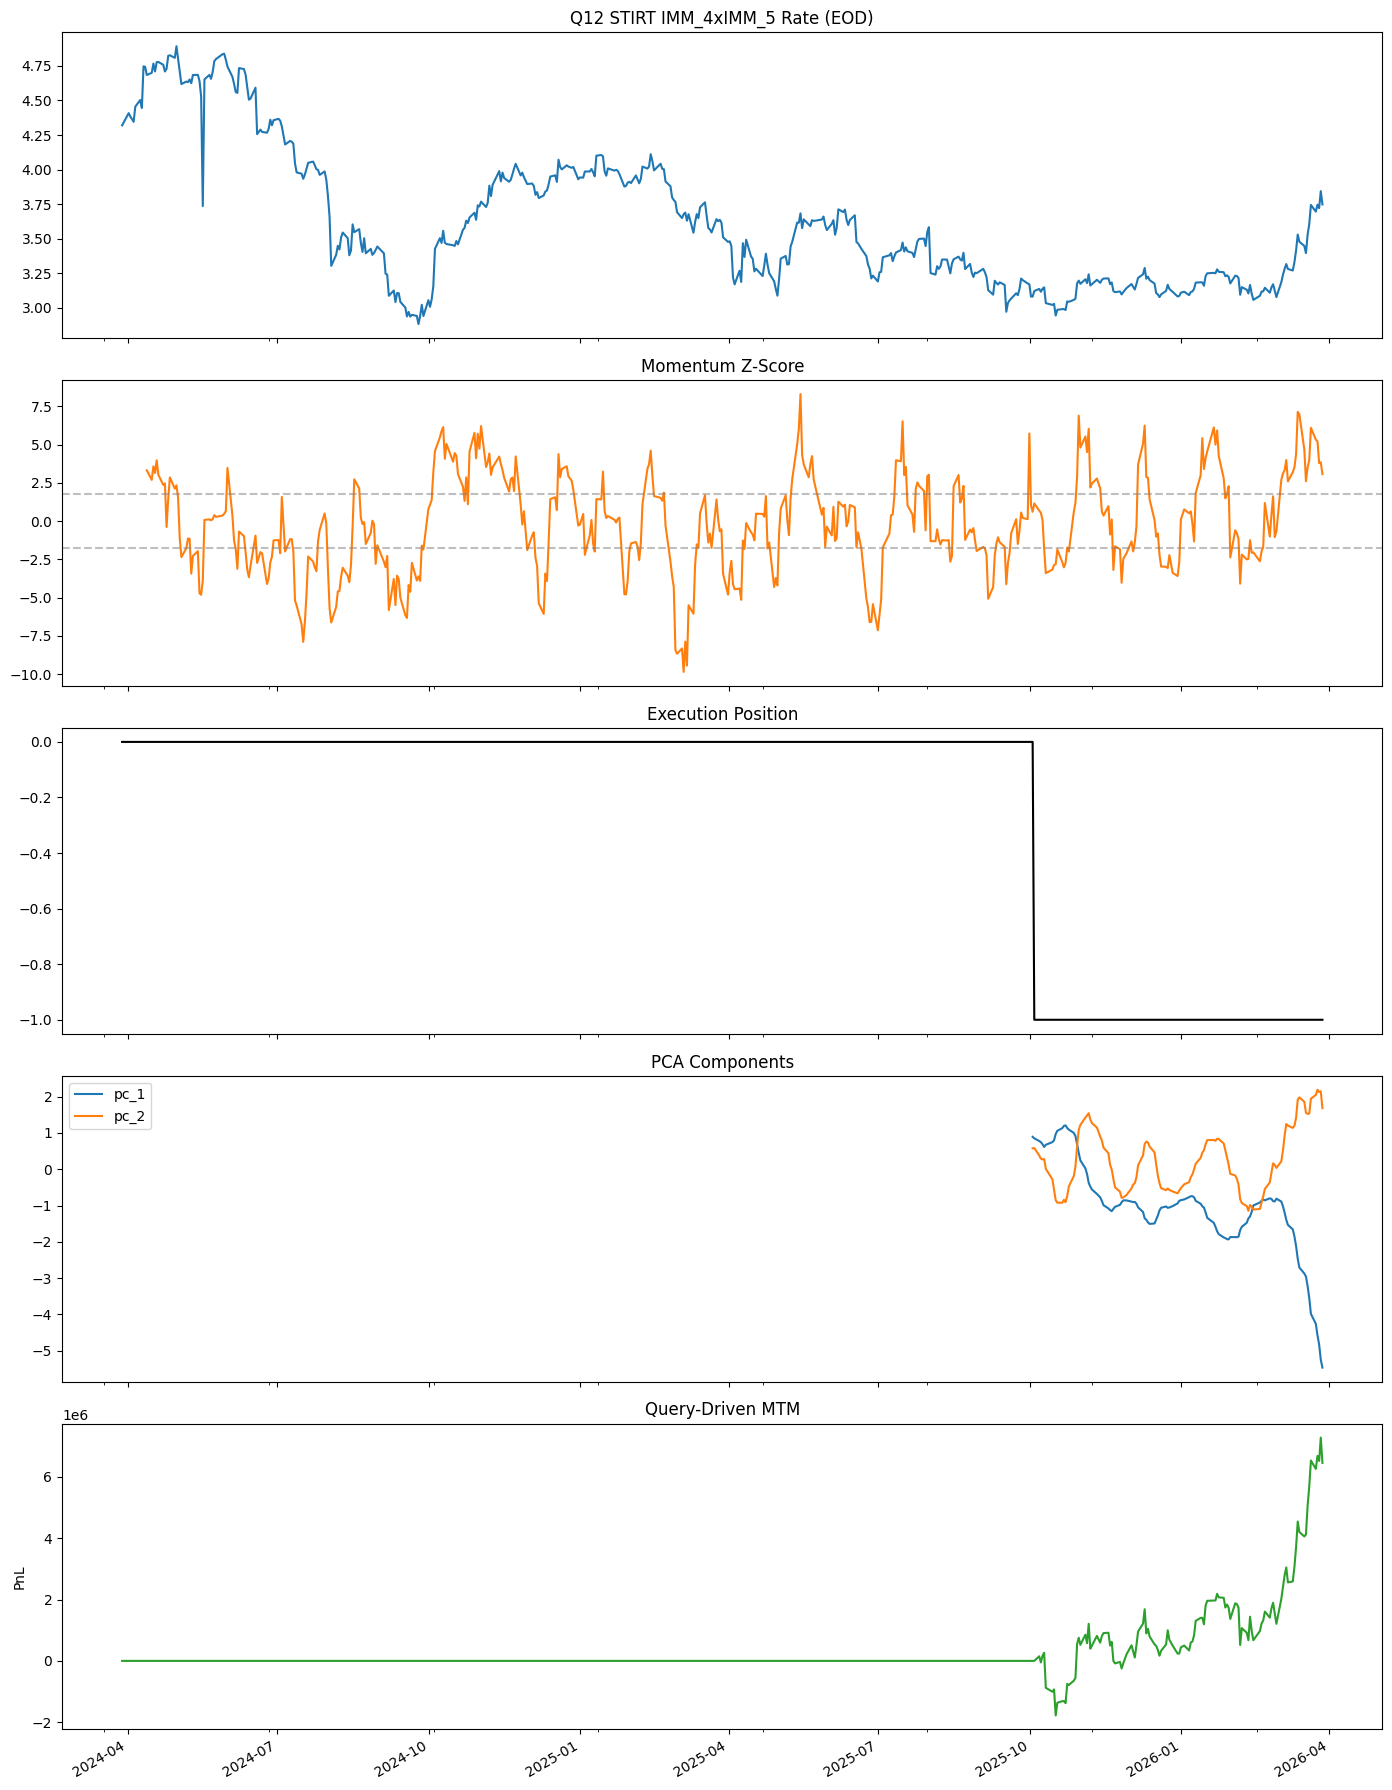

,timestamp,signal_key,raw_signal_key,position_id,signal_direction,order_type
0,2025-10-03 17:00:00-04:00,IMM_4xIMM_5,IMM_4xIMM_5,IMM_4xIMM_5|2025-10-03T17:00:00-04:00|1|leg1,-1,QueryOrder


In [36]:
# ── Diagnostic plots ─────────────────────────────────────────────────────
plot_df = pd.DataFrame(
    {
        "rate": signal_result.raw_series,
        "momentum_zscore": signal_result.indicator_frame["momentum_zscore"],
        "label": signal_result.indicator_frame["label"],
        "decision_score": signal_result.indicator_frame["decision_score"],
        "pc_1": signal_result.indicator_frame["pc_1"],
        "pc_2": signal_result.indicator_frame["pc_2"],
        "execution_position": signal_result.execution_position,
    }
).dropna(subset=["rate"])

fig, axes = plt.subplots(5, 1, figsize=(14, 18), sharex=True)

plot_df["rate"].plot(ax=axes[0], title="Q12 STIRT IMM_4xIMM_5 Rate (EOD)")
plot_df["momentum_zscore"].dropna().plot(
    ax=axes[1], title="Momentum Z-Score", color="tab:orange",
)
axes[1].axhline(1.75, color="gray", linestyle="--", alpha=0.5)
axes[1].axhline(-1.75, color="gray", linestyle="--", alpha=0.5)
plot_df["execution_position"].fillna(0.0).plot(
    ax=axes[2], title="Execution Position", color="black",
)
plot_df[["pc_1", "pc_2"]].dropna().plot(ax=axes[3], title="PCA Components")
query_backtest.mtm_history.plot(ax=axes[4], title="Query-Driven MTM", color="tab:green")
axes[4].set_ylabel("PnL")

plt.tight_layout()
plt.show()

query_backtest.order_frame.tail()